In [2]:
import sys
import numpy as np
import anndata as ad
import pandas as pd
import polars as pl

import src as scit

In [3]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')

In [3]:
lc_acet_imp = scit.tl.make_layer_config(
    "acet_imp",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth_imp = scit.tl.make_layer_config(
    "meth_imp",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

In [5]:
active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()
#active_rna = lc_rna.transform(rna, binarize=True).mean(axis=0).A1 > 0.006

In [ ]:
lmm = scit.tl.get_layer_feature_means(cttag, lc_meth_imp)
lma = scit.tl.get_layer_feature_means(cttag, lc_acet_imp)

AttributeError: module 'src.plotting.int' has no attribute 'historgram'

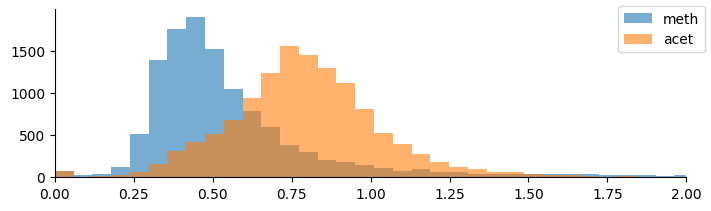

In [53]:
scit.pl.int.histogram([lmm, lma], ['meth', 'acet'], xminmax=(0,2), bins=300)
mask = lmm > 0.4
mask *= lma > 0.6

In [54]:
mask.sum()

np.int64(8344)

In [55]:
scit.tl.layer_pick_features(cttag, lc_meth_imp, mask)
scit.tl.layer_pick_features(cttag, lc_acet_imp, mask)
scit.adv.griddata_numerical(cttag, lc_meth_imp, min_cells=8)
scit.adv.griddata_numerical(cttag, lc_acet_imp, min_cells=8)

Info: Added Griddata to .uns[meth_imp]
Info: Added Griddata to .uns[acet_imp]


In [64]:
l = dict(
    gauss_kernel=(1,1), n_median_passes=1, all_feature_q_norm=0.99, 
    winsor_qs_high=0.98, data_range_q=0.98#, winsor_qs_low=0.96, winsor_set_low_zero=True
)
# _CON = 2.5
# for i, n, q in [(0, 'acet_imp', 0.97), (1, 'meth_imp', 0.96), (2, 'rna', 0.95)]:
#     s = data.get_slice(n,use_gauss=True)
#     scaler = 1/np.array([np.quantile(_s.ravel(), q) for _s in s])
#     data.X_gauss[:,:,:,i] = _CON*np.multiply(data.X_gauss[:,:,:,i].T, scaler).T
# 
# from src.advanced._hmm_data import hmm_data_corr_transform
# hmm_data_corr_transform(data, None, [0.97,0.97,0.97,1.0])
# 
# a=np.sign(data.X_gauss)
# data.X_gauss = a*(np.abs(data.X_gauss)**2.2)
# 
# #hmm_data_corr_transform(data, [0.1,0.1,0.1,0], None, set_low_zero=True)
# hmm_data_corr_transform(data, [0.2,0.2,0.2,0.0], None, q_is_p_max=True, set_low_zero=True)
scit.adv.griddata_apply_transformations(cttag, lc_meth_imp.layer, **(l | dict(set_data_range=(0, 10))))
scit.adv.griddata_apply_transformations(cttag, lc_acet_imp.layer, **(l | dict(set_data_range=(0, 10))))

Info: Added Griddata to .uns[t_meth_imp]
Info: Added Griddata to .uns[t_acet_imp]


In [61]:
#rna.uns['griddata']['t_rna']['z'] = rna.uns['griddata']['t_rna']['z']**2
#cttag.uns['griddata']['t_meth_imp']['z'] = cttag.uns['griddata']['t_meth_imp']['z']**2
#cttag.uns['griddata']['t_acet_imp']['z'] = cttag.uns['griddata']['t_acet_imp']['z']**2

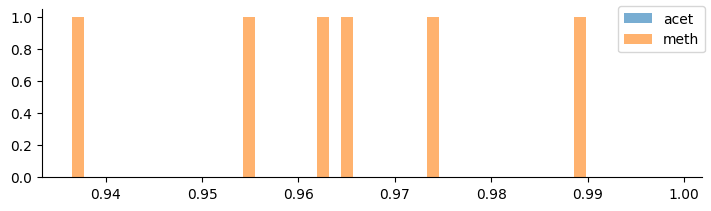

In [65]:
scit.set_defaults(figsize=(7,2))
scit.pl.int.histogram(
    [
    cttag.uns['griddata']['t_acet_imp']['z'].max(axis=(1,2)),
    cttag.uns['griddata']['t_meth_imp']['z'].max(axis=(1,2))
    ],
    [
        'acet', 'meth'
    ], max_normalize=False
)

In [66]:
features = cttag.uns['griddata']['meth_imp']['feature_names']
features

array(['gfzf', 'sisRNA:CR46358', 'Osi24', ..., 'gw', 'asRNA:CR44027',
       'Sox102F'], dtype='<U33')

In [67]:
df = scit.adv.griddata_correlations([cttag, cttag], ['t_acet_imp', 't_meth_imp'], features, spearman=False, signal_weighting=True)
df

res,var_name
f32,str
-0.573195,"""gfzf"""
0.114238,"""sisRNA:CR46358"""
-0.298753,"""Osi24"""
-0.098205,"""msps"""
0.03745,"""CG6013"""
…,…
0.365941,"""Zip102B"""
0.017104,"""Pur-alpha"""
-0.023708,"""gw"""


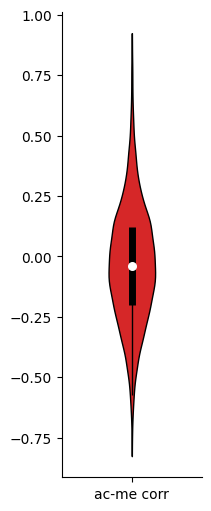

In [74]:
scit.set_defaults(figsize=(2,5))

_df = df.filter(pl.col('res').is_not_nan())
scit.pl.int.violin([_df['res']], ['ac-me corr'])#.savefig('private/newest/figures/acme_corr.pdf')

shape: (1, 2)
┌───────────┬──────────┐
│ res       ┆ var_name │
│ ---       ┆ ---      │
│ f32       ┆ str      │
╞═══════════╪══════════╡
│ -0.735588 ┆ grh      │
└───────────┴──────────┘


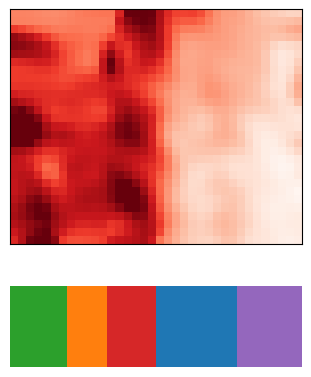

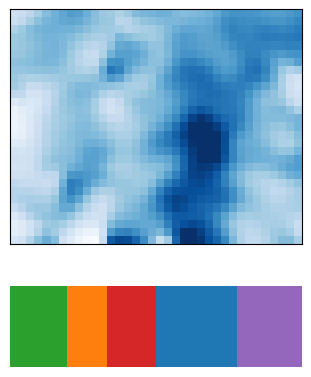

In [79]:
scit.set_defaults(figsize=(3,4))
gn = 'grh'

print(df.filter(pl.col('var_name')==gn))
scit.adv.pl.landscape2d(cttag, 't_meth_imp', gn, cmap='Reds')
scit.adv.pl.landscape2d(cttag, 't_acet_imp', gn, cmap='Blues')

In [77]:
df.write_csv('private/data/acme_corr.csv')

In [78]:
df.filter(pl.col('var_name') == 'vvl')

res,var_name
f32,str
-0.741156,"""vvl"""
